
 [분석 결과 1] 월별 매출 총합 요약
 -  1월 총매출: 2,795,000.000000원 (279.5만 원)
 -  2월 총매출: 800,000.000000원 (80.0만 원)
 -  3월 총매출: 2,035,000.000000원 (203.5만 원)
 -  4월 총매출: 1,950,000.000000원 (195.0만 원)
----------------------------------------


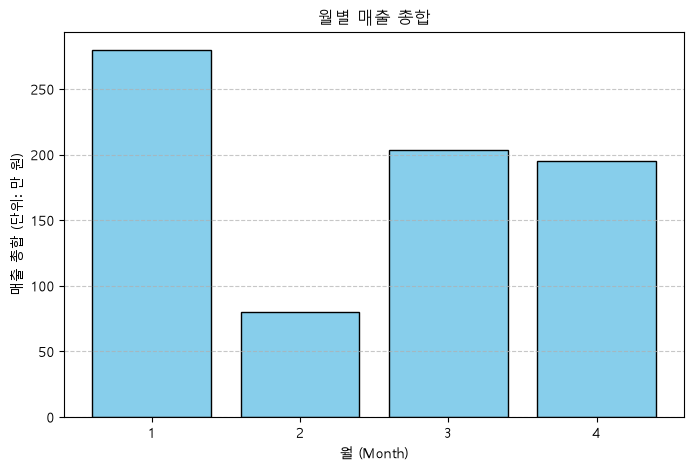


 [분석 결과 2] 고객별 누적 매출 기여도 요약
 - 김철수: 2,145,000.000000원 (28.3%)
 - 홍길동: 1,765,000.000000원 (23.3%)
 - 이순신: 1,430,000.000000원 (18.9%)
 - 정수민: 1,265,000.000000원 (16.7%)
 - 박영희: 490,000.000000원 (6.5%)
 - 최민수: 485,000.000000원 (6.4%)
----------------------------------------


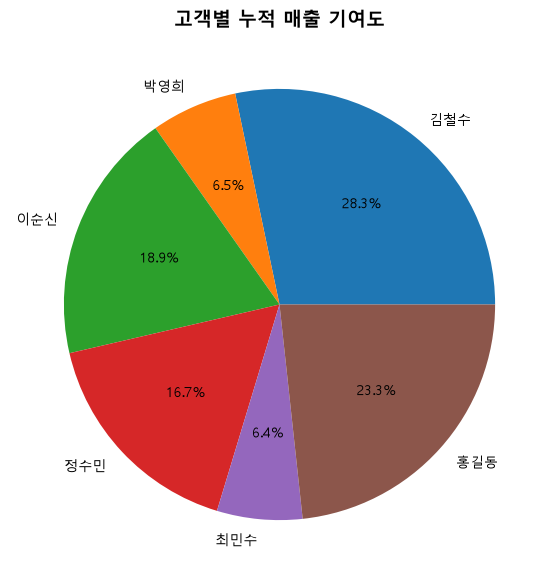

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# [환경 설정] Matplotlib 한글 폰트 깨짐 방지 
plt.rc('font', family='Malgun Gothic') # Windows 기본 한글 폰트 설정

# ==============================================================================
# [클래스 정의] 고객 구매 데이터 마케팅 분석 클래스
# ==============================================================================
class CustomerSalesAnalysis:

    def __init__(self, data):
        """
        클래스 생성자: 데이터프레임 초기화 및 전처리(시계열 변환, 파생변수 생성)
        """
        self.df = data
        
        # 데이터 전처리: 구매일자 컬럼을 문자열에서 시계열(Datetime) 객체로 변환
        self.df['구매일자'] = pd.to_datetime(self.df['구매일자'])
        
        # 파생변수 생성: 수량과 단가를 곱하여 건별 '총매출' 계산
        self.df['총매출'] = self.df['수량'] * self.df['단가']

    def analyze_monthly_sales(self):
        """
        분석 및 시각화 1: 월별 매출 총합 집계 및 막대 그래프 출력
        """
        # '구매일자'에서 월(month)을 추출하여 월별 총매출의 합계 집계
        monthly_sales = self.df.groupby(self.df['구매일자'].dt.month)['총매출'].sum()
        
        # 콘솔 출력 메시지 및 결과 해석 제공 -- 주석 가능
        print("\n" + "="*40)
        print(" [분석 결과 1] 월별 매출 총합 요약")
        print("="*40)
        for month, sales in monthly_sales.items():
            print(f" - {month:2d}월 총매출: {sales:1,f}원 ({sales/10000:,.1f}만 원)")
        print("-"*40)

        # 시각화 가독성을 위해 금액 단위를 '만 원'으로 변환
        monthly_sale_in_manwon = monthly_sales / 10000

        # 막대 그래프(Bar Chart) 생성 및 스타일 설정
        plt.figure(figsize=(8, 5))
        plt.bar(monthly_sale_in_manwon.index, monthly_sale_in_manwon.values, color='skyblue', edgecolor='black')
        plt.title('월별 매출 총합')
        plt.xlabel('월 (Month)')
        plt.xticks(monthly_sale_in_manwon.index)
        plt.ylabel('매출 총합 (단위: 만 원)')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.show()
        
    def analyze_customer_contribution(self):
        """
        분석 및 시각화 2: 고객별 누적 매출 기여도 집계 및 파이 차트 출력
        """
        # '고객명'을 기준으로 그룹화하여 고객별 누적 매출 합계 집계
        customer_sales = self.df.groupby('고객명')['총매출'].sum()
        total_sales = customer_sales.sum()
        
        # 콘솔 출력 메시지 및 결과 해석 제공 -- 주석 가능
        print("\n" + "="*40)
        print(" [분석 결과 2] 고객별 누적 매출 기여도 요약")
        print("="*40)
        for customer, sales in customer_sales.sort_values(ascending=False).items():
            percentage = (sales / total_sales) * 100
            print(f" - {customer}: {sales:1,f}원 ({percentage:.1f}%)")
        print("-"*40)
        
        # 파이 차트(Pie Chart) 생성 및 스타일 설정
        plt.figure(figsize=(7, 7))
        plt.pie(customer_sales.values, labels=customer_sales.index, autopct='%1.1f%%')       
        plt.title('고객별 누적 매출 기여도', fontsize=14, fontweight='bold')
        plt.show()


# ==============================================================================
# [메인 실행부] 데이터 로드 및 분석 수행
# ==============================================================================
# CSV 파일로부터 원본 데이터 로드
df = pd.read_csv('data.csv')

# 분석 클래스 인스턴스 생성
analyzer = CustomerSalesAnalysis(df)

# 각 분석 메서드 호출을 통한 시각화 결과 출력
analyzer.analyze_monthly_sales()
analyzer.analyze_customer_contribution()